# Autolayout formulation

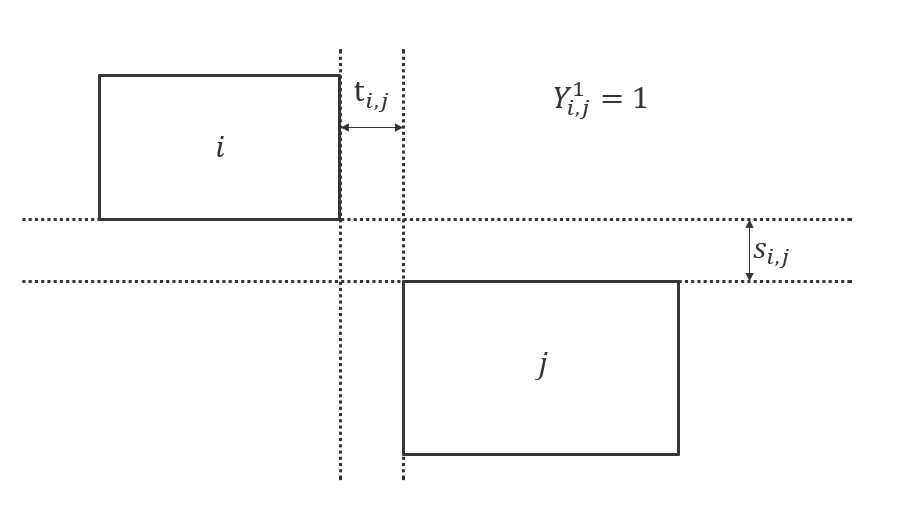

\begin{gather}
\min \; l_f + w_f + \sum_{i,j} c_{i,j}( t_{i,j} + s_{i,j}) \\
\text{Minimze the sum of facility dimensions and weighted Manhattan distances between blocks}\\
\textrm{s.t.} \;l_f \ge x_i + l_i \; \forall  i \in  N \\
\text{The length of the facility contains all blocks}\\ 
w_f \ge y_i + w_i \; \forall  i \in  N \\ 
\text{The width of the facility contains all blocks}\\
x_i \le UB \; \forall i \in  N \\ 
y_i \le UB \; \forall i \in  N \\
\text{Worst case bounds on dimensions where $UB = \sum_{i} max(l_i,w_i)$} \\
\left[
\begin{array}{c}
Y_{i,j}^1\\
x_j - (x_i + l_i) = t_{i,j}\\
y_i - (y_j + w_j) \le s_{i,j}\\
y_j - (y_i + w_i) \le s_{i,j}\\ 
\text{$i$ is left of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^2\\
 x_i - (x_j + l_j) = t_{i,j}\\
 y_i - (y_j + w_j) \le s_{i,j}\\
y_j - (y_i + w_i) \le s_{i,j}\\ 
\text{$i$ is right of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^3 \\
y_i - (y_j + w_j) = t_{i,j} \\
 x_i - (x_j + l_j) \le s_{i,j}\\
x_j - (x_i + l_i) \le s_{i,j}\\ 
\text{$i$ is above $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^4 \\
y_j - (y_i + w_i)=t_{i,j}  \\
 x_i - (x_j + l_j) \le s_{i,j}\\
x_j - (x_i + l_i) \le s_{i,j}\\ 
\text{$i$ is below $j$}
\end{array}
\right] \\
\\ 
t_{i,j}\ge d_{i,j} \;  \forall i,j \in N, j <i\\ 
\text{Minimum distance between units. Bound is conservative due to the disjunction formulaion.}\\
\\
\left[
\begin{array}{c}
Y_{i}^5 \\
l_i = l^0_i \\
w_i = w^0_i\\
\text{Default orientation}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i}^6\\
l_i = w^0_i \\
w_i = l^0_i \\
\text{Rotated orientation}
\end{array}
\right] \\ 
\\
l_f,w_f,l_i,w_i,x_i,y_i,s_{i,j},t_{i,j} \in \mathbb{R}^1_+ \\
Y_{i,j}^1,Y_{i,j}^2,Y_{i,j}^3,Y_{i,j}^4,Y_{i}^5,Y_{i}^6 \in \text{ \{ True, False \}  } \\
\forall i,j \in N, j <i
\end{gather}
GDP fromulation adapted from: https://www.sciencedirect.com/science/article/abs/pii/S0098135405000992

Similar plant layout problem: https://pubs.acs.org/doi/10.1021/ie980146v

Symmetry breaking: https://skoge.folk.ntnu.no/prost/proceedings/focapd_2004/pdffiles/papers/075_46.pdf

In [1]:
import random
import pandas as pd
import visuals as vs
#warnings.filterwarnings('ignore')
from pyomo.environ import (ConcreteModel, NonNegativeReals, Objective, Param,
                           Set, SolverFactory, TransformationFactory, Var, value, RangeSet)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe



def create_model(n,w_0,l_0,c_0,d_0,rotate=0,sym=0):
    
    ## Model
    m = ConcreteModel()
    
    ## Sets
    m.n = Set(ordered=True, initialize=RangeSet(1, n) )
    def rec_pairs_filter(m, i, j):
        return i > j
    m.p = Set(initialize=m.n * m.n,  dimen=2, filter=rec_pairs_filter)

    ## Parameters
    # Width and length of each rectangle
    m.w0 = Param(m.n, initialize= w_0)
    m.l0 = Param(m.n, initialize = l_0)
    #cost
    m.c = Param(m.p, initialize = c_0 )
    #distance constraint
    m.d = Param(m.p, initialize = d_0 )

    

    # Upperbound 
    m.UB = Param(initialize=sum(max([m.l0[i],m.w0[i]]) for i in m.n))

    ## Variables
    # x (length) and y (width) coordinates of each of the rectangles
    m.x = Var(m.n,bounds=(0,m.UB))
    m.y = Var(m.n,bounds=(0,m.UB))
    m.t = Var(m.p,bounds=(0,m.UB))
    m.s = Var(m.p,bounds=(0,m.UB))
    m.l =Var(m.n,bounds=(0,m.UB))
    m.w = Var(m.n,bounds=(0,m.UB))


    # facility width and length
    m.l_f = Var(within=NonNegativeReals)
    m.w_f = Var(within=NonNegativeReals)

    ## Constraints
    @m.Constraint(m.n)
    def facility_length(m, i):
        return m.l_f >= m.x[i] + m.l[i]
    @m.Constraint(m.n)
    def facility_width(m, i):
        return m.w_f >= m.y[i] + m.w[i]
    @m.Constraint(m.p)
    def min_dist(m, i,j):
        return m.t[i,j] >= m.d[i,j]


    if sym==1:
        @m.Constraint()
        #break horizontal symmetry
        def sym_1(m):
            return m.x[1] + m.l[1]/2 <= m.x[2] + m.l[2] /2
    
        @m.Constraint()
        #break vertical symmetry
        def sym_2(m):
            return m.y[1] + m.w[1]/2 <= m.y[2] + m.w[2] /2
        

    ## Objective
    m.obj = Objective(expr=m.l_f+m.w_f +   sum( m.c[i,j] * (m.t[i,j] + m.s[i,j]) for i,j in m.p)    )     
    
    @m.Disjunction(m.p)
    def no_overlap(m, i, j):
        return [
            [m.x[j] - (m.x[i] + m.l[i]) == m.t[i,j],
            m.y[i] - (m.y[j] + m.w[j]) <= m.s[i,j],
             m.y[j] - (m.y[i] + m.w[i])<=m.s[i,j]    ],
            
            [m.x[i] - (m.x[j]+m.l[j]) == m.t[i,j],
             m.y[i] - (m.y[j] + m.w[j]) <= m.s[i,j],
             m.y[j] - (m.y[i] + m.w[i]) <= m.s[i,j]   ],
            
            [m.y[i] - (m.y[j] +m.w[j]) == m.t[i,j] ,
             m.x[i] - (m.x[j] + m.l[j]  ) <= m.s[i,j] ,
              m.x[j] - (m.x[i] + m.l[i] ) <= m.s[i,j]  ],

            
            [m.y[j] - (m.y[i] + m.w[i]) == m.t[i,j]  ,
             m.x[i] - (m.x[j] + m.l[j]  ) <= m.s[i,j] ,
              m.x[j] - (m.x[i] + m.l[i] ) <= m.s[i,j]  ]           
            ]
    if rotate ==1:
        @m.Disjunction(m.n)
        def rotate(m, i):
            return [
                [m.l[i] == m.l0[i],
                m.w[i] == m.w0[i] ],
                
                [m.l[i] == m.w0[i],
                m.w[i] == m.l0[i] ]     ]
        if sym == 1:
            #break diagonal symmetry
            @m.Constraint()
            def sym_3(m):
                return m.l[1] == m.l0[1]  
            
    else:
        @m.Constraint(m.n)
        def fix_l(m, i):
            return m.l[i] == m.l0[i]
        @m.Constraint(m.n)
        def fix_w(m, i):
            return m.w[i] == m.w0[i] 
    return m

In [2]:
num =6
random.seed(1)
#random blocks
w_0 = {i: random.randint(1, 2) for i in range(1,num+1)}
l_0={i: random.randint(1, 2) for i in range(1,num+1)}

#random pipes
#c_0 = {(i,j):random.randint(1,10) for i in range(1,num+1) for j in range(1,num+1) if i > j}
#pipes to pipe rack only
c_0 = {(i,j):1 if j == 1 else 0 for i in range(1,num+1) for j in range(1,num+1) if i>j}   


#minimum dist

d_0 = {(i,j):1 for i in range(1,num+1) for j in range(1,num+1) if i > j}
   



In [3]:
m = create_model(num,w_0,l_0,c_0,d_0,rotate = 1,sym=1)
#TransformationFactory('gdp.bigm').apply_to(m)
#TransformationFactory('gdp.hull').apply_to(m)
TransformationFactory('gdp.mbigm').apply_to(m)
#TransformationFactory('gdp.cuttingplane').apply_to(m)
# Solve and print the solution

SolverFactory('appsi_highs').solve(m, tee=True)


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
MIP has 315 rows; 128 cols; 1584 nonzeros; 72 integer variables (72 binary)
Coefficient ranges:
  Matrix  [5e-01, 3e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+01]
  RHS     [1e+00, 2e+00]
Presolving model
281 rows, 103 cols, 1300 nonzeros 0s
175 rows, 103 cols, 824 nonzeros 0s
169 rows, 97 cols, 812 nonzeros 0s
Presolve reductions: rows 169(-146); columns 97(-31); nonzeros 812(-772) 

Solving MIP model with:
   169 rows
   97 cols (63 binary, 0 integer, 0 implied int., 34 continuous, 0 domain fixed)
   812 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

       

{'Problem': [{'Lower bound': 15.998409090909105, 'Upper bound': 15.999999, 'Number of objectives': 1, 'Number of constraints': 0, 'Number of variables': 0, 'Sense': 'minimize'}], 'Solver': [{'Status': 'ok', 'Termination condition': 'optimal', 'Termination message': 'TerminationCondition.optimal'}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

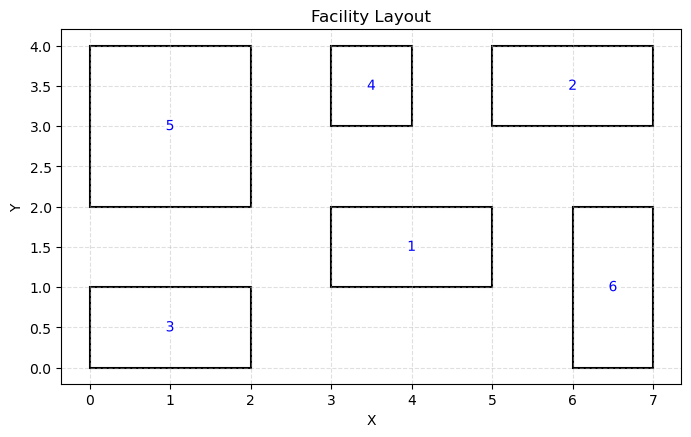

,Rectangle,X (Lower Left),Y (Lower Left),Length (X),Width (Y)
0,1,3,1,2,1
1,2,5,3,2,1
2,3,0,0,2,1
3,4,3,3,1,1
4,5,0,2,2,2
5,6,6,0,1,2


In [4]:
vs.plot_rect_layout(m, title="Facility Layout")
vs.rect_table(m,decimals = 0)

In [5]:
print(c_0)

{(2, 1): 1, (3, 1): 1, (3, 2): 0, (4, 1): 1, (4, 2): 0, (4, 3): 0, (5, 1): 1, (5, 2): 0, (5, 3): 0, (5, 4): 0, (6, 1): 1, (6, 2): 0, (6, 3): 0, (6, 4): 0, (6, 5): 0}
